<h1>Импорт библиотек

In [2]:
import numpy as np
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


<h1>Задача 1. Дан набор из $p$ матриц размерностью $(n, n)$ и $p$ векторов размерностью $(n, 1)$, найти сумму произведений матриц на векторы. Написать тесты для кода

In [3]:
def sum_prod(X, V):
    return sum(X[i] @ V[i] for i in range(len(X)))

X = [np.array([[1, 0], [0, 1]]), np.array([[2, 0], [0, 2]])]
V = [np.array([[1], [2]]), np.array([[3], [4]])]
assert np.array_equal(sum_prod(X, V), np.array([[7], [10]]))
print("Все тесты пройдены!")

Все тесты пройдены!


<h1>Задача 2. Дана матрица M, напишите функцию, которая бинаризует матрицу по некоторому threshold (то есть, все значения большие threshold становятся равными 1, иначе 0). Напишите тесты для кода

In [4]:
def binarize(M, threshold=0.5):
    return (M > threshold).astype(int)

M = np.array([[0.3, 0.7], [0.5, 0.9]])
assert np.array_equal(binarize(M), np.array([[0, 1], [0, 1]]))
print("Все тесты пройдены!")

Все тесты пройдены!


<h1>Задача 3. Напишите функцию, которая возвращает уникальные элементы из каждой строки матрицы. Напишите такую же функцию, но для столбцов. Напишите тесты для кода

In [5]:
def unique_rows(mat):
    return [list(np.unique(row)) for row in mat]

def unique_columns(mat):
    return [list(np.unique(col)) for col in mat.T]

M = np.array([[1, 2, 2], [3, 3, 4]])
assert unique_rows(M) == [[1, 2], [3, 4]]
assert unique_columns(M) == [[1, 3], [2, 3], [2, 4]]
print("Все тесты пройдены!")

Все тесты пройдены!


<h1>Задача 4. Напишите функцию, которая заполняет матрицу с размерами $(m, n)$ случайными числами, распределенными по нормальному закону. Затем считает мат. ожидание и дисперсию для каждого из столбцов и строк, а также строит для каждой строки и столбца гистограмму значений (использовать функцию hist из модуля matplotlib.plot)

Мат. ожидание по строкам: [ 1.24975292 -0.0667826   0.05305077]
Мат. ожидание по столбцам: [ 1.57462716  0.01984648 -0.30783716  0.36139164]
Дисперсия по строкам: [1.41392942 1.28921887 0.16791867]
Дисперсия по столбцам: [1.92695467 0.21402321 0.27521005 0.79889805]


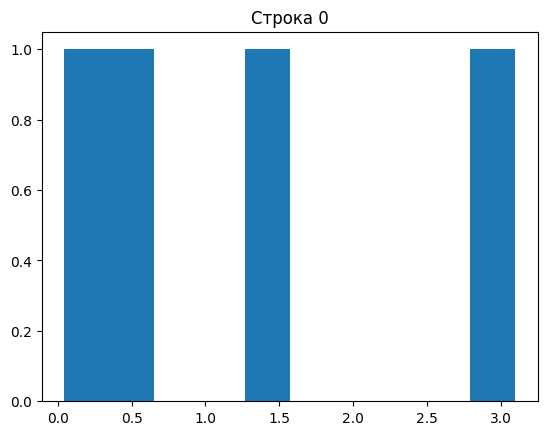

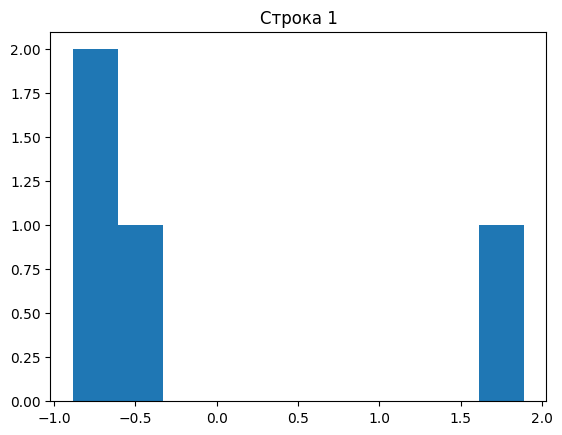

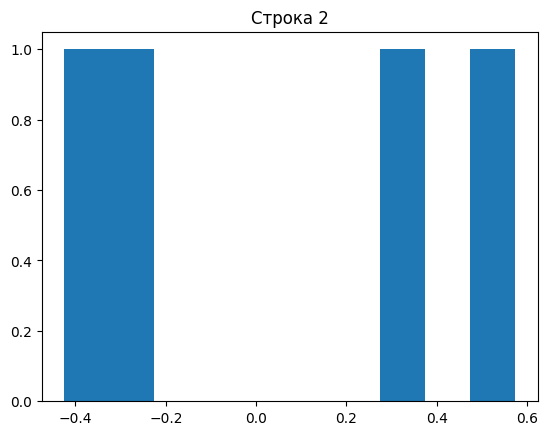

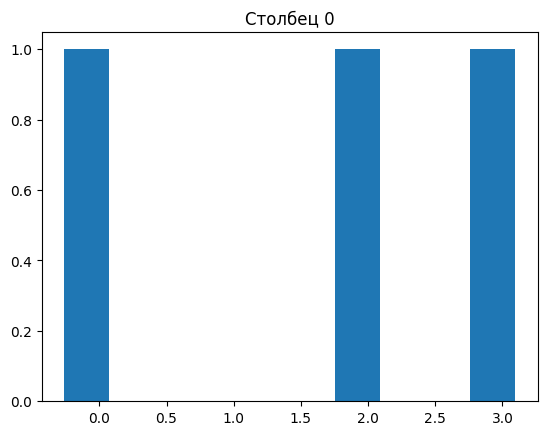

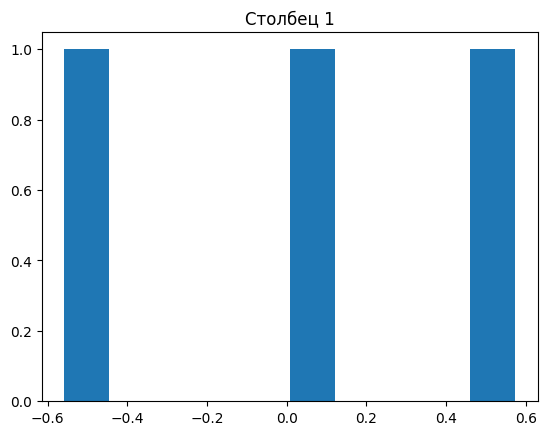

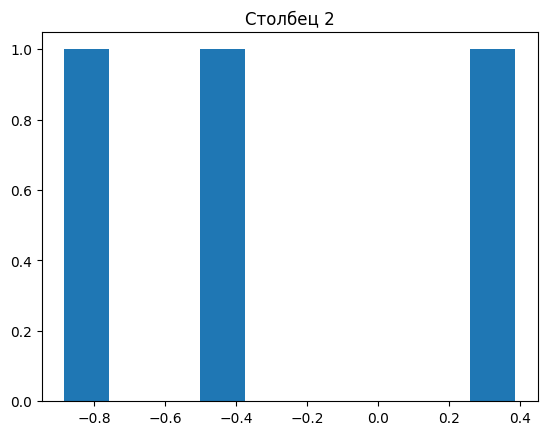

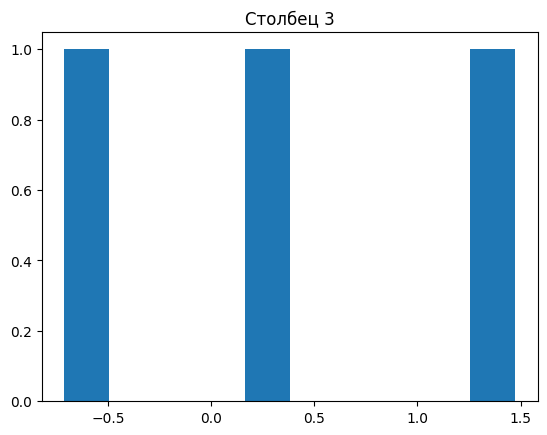

In [6]:
def analyze_matrix(m, n):
    M = np.random.normal(0, 1, (m, n))
    
    print("Мат. ожидание по строкам:", np.mean(M, axis=1))
    print("Мат. ожидание по столбцам:", np.mean(M, axis=0))
    print("Дисперсия по строкам:", np.var(M, axis=1))
    print("Дисперсия по столбцам:", np.var(M, axis=0))
    
    for i, row in enumerate(M):
        plt.figure()
        plt.hist(row)
        plt.title(f"Строка {i}")
        plt.show()
    
    for j in range(M.shape[1]):
        plt.figure()
        plt.hist(M[:, j])
        plt.title(f"Столбец {j}")
        plt.show()

analyze_matrix(3, 4)

<h1>Задача 5. Напишите функцию, которая заполняет матрицу $(m, n)$ в шахматном порядке заданными числами $a$ и $b$. Напишите тесты для кода

In [7]:
def chess(m, n, a, b):
    M = np.zeros((m, n))
    M[::2, ::2] = a
    M[1::2, 1::2] = a
    M[::2, 1::2] = b
    M[1::2, ::2] = b
    return M

assert np.array_equal(chess(2, 2, 1, 0), np.array([[1, 0], [0, 1]]))
assert np.array_equal(chess(2, 2, 0, 1), np.array([[0, 1], [1, 0]]))
print("Все тесты пройдены!")

Все тесты пройдены!


<h1>Задача 6. Напишите функцию, которая отрисовывает прямоугольник с заданными размерами (a, b) на изображении размера (m, n), цвет фона задайте в схеме RGB, как и цвет прямоугольника. Цвета также должны быть параметрами функции. Напишите аналогичную функцию но для овала с полуосями a и b. Напишите тесты для кода.
Примечание: уравнение эллипса (границы овала) можно записать как:
<h1>$\frac{(x-x_0)^2}{a^2}+\frac{(y-y_0)^2}{b^2}=1$

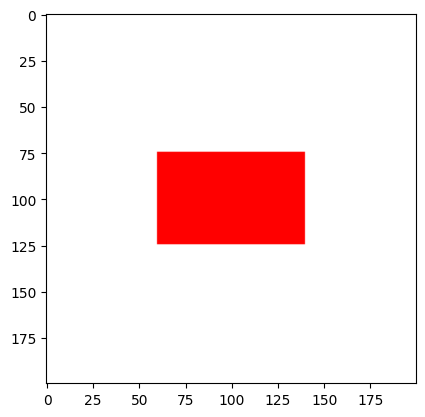

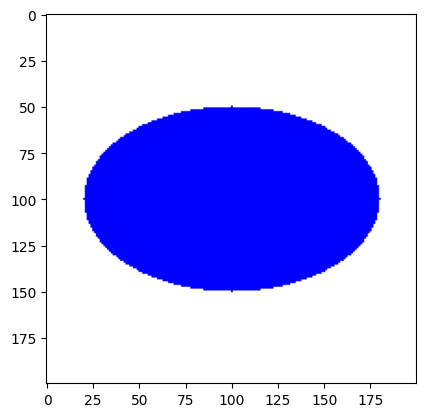

In [8]:
def draw_rectangle(a, b, m, n, rectangle_color, background_color):
    img = np.full((m, n, 3), background_color)
    x0, y0 = m // 2 - a // 2, n // 2 - b // 2
    img[x0:x0+a, y0:y0+b] = rectangle_color
    plt.imshow(img)
    plt.show()

def draw_ellipse(a, b, m, n, ellipse_color, background_color):
    img = np.full((m, n, 3), background_color)
    x0, y0 = m // 2, n // 2
    for x in range(m):
        for y in range(n):
            if (x - x0)**2 / a**2 + (y - y0)**2 / b**2 <= 1:
                img[x, y] = ellipse_color
    plt.imshow(img)
    plt.show()

draw_rectangle(50, 80, 200, 200, [255, 0, 0], [255, 255, 255])
draw_ellipse(50, 80, 200, 200, [0, 0, 255], [255, 255, 255])

<h1>Задача 7. Дан некий временной ряд. Для данного ряда нужно найти его: математическое ожидание, дисперсию, СКО, найти все локальные максимумы и минимумы (локальный максимум - это точка, которая больше своих соседних точек, а локальный минимум - это точка, которая меньше своих соседей), а также вычислить для данного ряда другой ряд, получаемый методом скользящего среднего с размером окна $p$.
<h1>Примечание: метод скользящего среднего подразумевает нахождение среднего из подмножетсва ряда размером $p$

In [9]:
series = np.array([1, 3, 2, 5, 4, 7, 6, 8])

print("Мат. ожидание:", np.mean(series))
print("Дисперсия:", np.var(series))
print("СКО:", np.std(series))

local_max = [i for i in range(1, len(series)-1) if series[i] > series[i-1] and series[i] > series[i+1]]
local_min = [i for i in range(1, len(series)-1) if series[i] < series[i-1] and series[i] < series[i+1]]
print("Локальные максимумы (индексы):", local_max)
print("Локальные минимумы (индексы):", local_min)

def moving_average(s, p):
    return np.array([np.mean(s[i:i+p]) for i in range(len(s) - p + 1)])

print("Скользящее среднее (p=3):", moving_average(series, 3))

Мат. ожидание: 4.5
Дисперсия: 5.25
СКО: 2.29128784747792
Локальные максимумы (индексы): [1, 3, 5]
Локальные минимумы (индексы): [2, 4, 6]
Скользящее среднее (p=3): [2.         3.33333333 3.66666667 5.33333333 5.66666667 7.        ]


<h1> Задача 8. Дан некоторый вектор с целочисленными метками классов, напишите функцию, которая выполняет one-hot-encoding для данного вектора
<h1> One-hot-encoding - представление, в котором на месте метки некоторого класса стоит 1, в остальных позициях стоит 0. Например для вектора [0, 2, 3, 0] one-hot-encoding выглядит как: [[1, 0, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1], [1, 0, 0, 0]]

In [10]:
def one_hot_encoding(v):
    n_classes = max(v) + 1
    result = np.zeros((len(v), n_classes), dtype=int)
    for i, label in enumerate(v):
        result[i, label] = 1
    return result

v = [0, 2, 3, 0]
expected = np.array([[1,0,0,0],[0,0,1,0],[0,0,0,1],[1,0,0,0]])
assert np.array_equal(one_hot_encoding(v), expected)
print("Все тесты пройдены!")

Все тесты пройдены!
